# Transformers, what can they do?

In this section, we will look at what Transformer models can do and use our first tool from the `🤗 Transformers library`: the `pipeline()` function.

## Transformers are everywhere!

Transformer models are used to solve all kinds of tasks across different modalities, including natural language processing (NLP), computer vision, audio processing, and more. Here are some of the companies and organizations using Hugging Face and Transformer models, who also contribute back to the community by sharing their models:

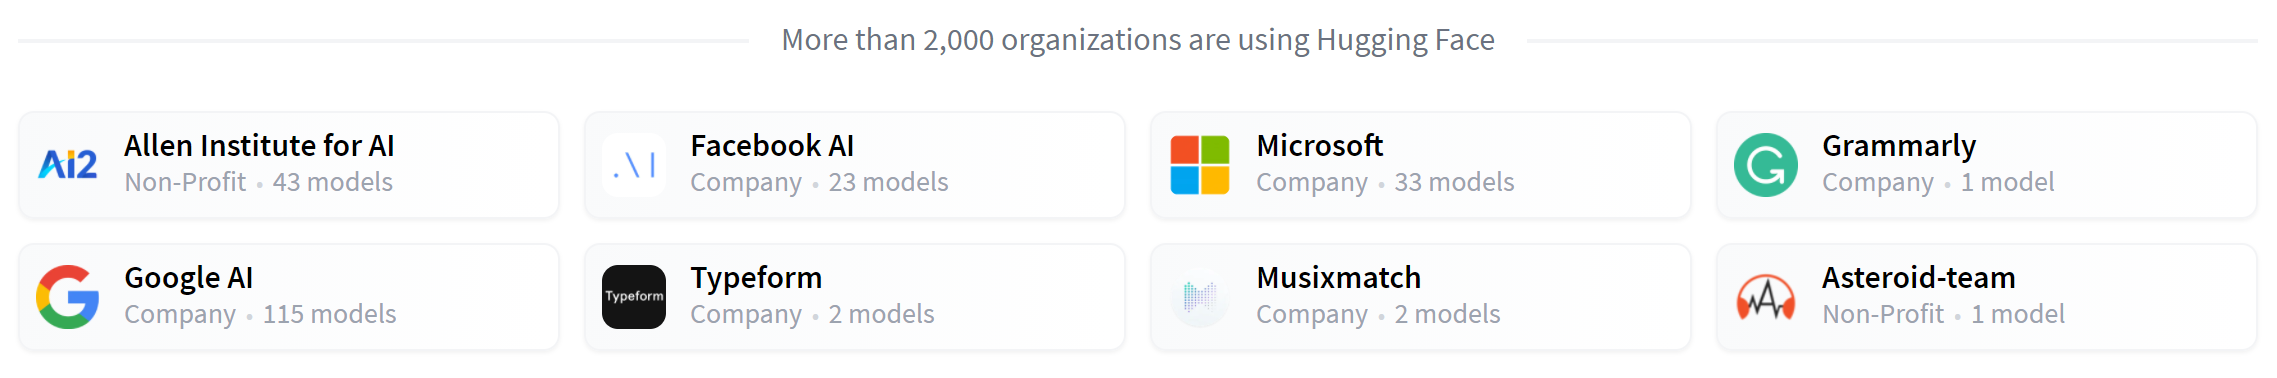

The <a href="https://github.com/huggingface/transformers">`🤗 Transformers`</a> library provides the functionality to create and use those shared models. The <a href="https://huggingface.co/models">`Model Hub`</a> contains millions of pretrained models that anyone can download and use. You can also upload your own models to the Hub!

> [!WARNING]
>
> The Hugging Face Hub is not limited to Transformer models. Anyone can share any kind of models or datasets they want! Create a <a href="https://huggingface.co/join">huggingface.co</a> account to benefit from all available features!

Before diving into how Transformer models work under the hood, let’s look at a few examples of how they can be used to solve some interesting NLP problems.

## Working with pipelines

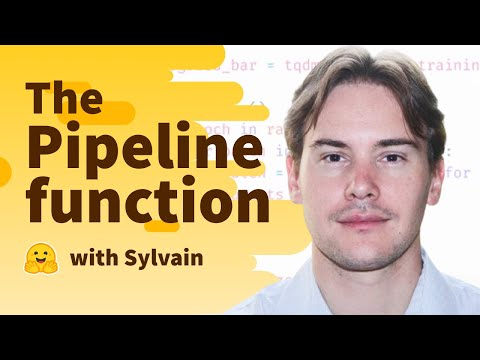

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("tiZFewofSLM", width=800, height=450)

The most basic object in the `🤗 Transformers` library is the `pipeline()` function. It connects a model with its necessary preprocessing and postprocessing steps, allowing us to directly input any text and get an intelligible answer:

In [2]:
from transformers.utils.logging import disable_progress_bar
disable_progress_bar()

In [3]:
from transformers import pipeline

classifier = pipeline(
    task="sentiment-analysis", 
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english",
)

In [4]:
classifier("I've been waiting for a HuggingFace course my whole life.")

[{'label': 'POSITIVE', 'score': 0.9598049521446228}]

---

We can even pass several sentences!

In [5]:
classifier([
    "I've been waiting for a HuggingFace course my whole life.", 
    "I hate this so much!"
])

[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

---

By default, this pipeline selects a particular pretrained model that has been fine-tuned for sentiment analysis in English. The model is downloaded and cached when you create the `classifier` object. If you rerun the command, the cached model will be used instead and there is no need to download the model again.

There are three main steps involved when you pass some text to a pipeline:

1. The text is preprocessed into a format the model can understand.
2. The preprocessed inputs are passed to the model.
3. The predictions of the model are post-processed, so you can make sense of them.

## Available pipelines for different modalities

The `pipeline()` function supports multiple modalities, allowing you to work with text, images, audio, and even multimodal tasks. In this course we’ll focus on text tasks, but it’s useful to understand the transformer architecture’s potential, so we’ll briefly outline it.

Here’s an overview of what’s available:

> For a full and updated list of pipelines, see the `🤗 Transformers` documentation.

### Text pipelines

- **text-generation:** Generate text from a prompt
- **text-classification:** Classify text into predefined categories
- **summarization:** Create a shorter version of a text while preserving key information
- **translation:** Translate text from one language to another
- **zero-shot-classification:** Classify text without prior training on specific labels
- **feature-extraction:** Extract vector representations of text

### Image pipelines

- **image-to-text:** Generate text descriptions of images
- **image-classification:** Identify objects in an image
- **object-detection:** Locate and identify objects in images

### Audio pipelines

- **automatic-speech-recognition:** Convert speech to text
- **audio-classification:** Classify audio into categories
- **text-to-speech:** Convert text to spoken audio

### Multimodal pipelines

- **image-text-to-text:** Respond to an image based on a text prompt

Let’s explore some of these pipelines in more detail!

## Zero-shot classification

We’ll start by tackling a more challenging task where we need to classify texts that haven’t been labelled. This is a common scenario in real-world projects because annotating text is usually time-consuming and requires domain expertise. For this use case, the zero-shot-classification pipeline is very powerful: it allows you to specify which labels to use for the classification, so you don’t have to rely on the labels of the pretrained model. You’ve already seen how the model can classify a sentence as positive or negative using those two labels — but it can also classify the text using any other set of labels you like.

In [6]:
from transformers import pipeline

classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli"
)

In [7]:
classifier(
    sequences="This is a course about the Transformers library",
    candidate_labels=[
        "education", 
        "politics", 
        "business"
    ]
)

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445963859558105, 0.11197596788406372, 0.04342765361070633]}

---

This pipeline is called zero-shot because you don’t need to fine-tune the model on your data to use it. 

It can directly return probability scores for any list of labels you want!

> ✏️ Try it out! Play around with your own sequences and labels and see how the model behaves.

## Text generation

In [8]:
from transformers import pipeline

generator = pipeline(
    task="text-generation",
    model="HuggingFaceTB/SmolLM3-3B"
)

In [ ]:
generator("In this course, we will teach you how to")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
